In [1]:

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from collections import defaultdict

# Load the data files
print("Loading data files...")

# Load N=10^7 results
df_N7 = pd.read_csv('N10^7_detailed_results.csv')
print("\nN=10^7 data loaded:")
print(df_N7.head())
print(f"\nShape: {df_N7.shape}")
print(f"\nColumns: {df_N7.columns.tolist()}")

# Load N=10^6 results
with open('detailed_results_N1e6.pkl', 'rb') as f:
 data_N6 = pickle.load(f)
print("\nN=10^6 data loaded")
print(f"Keys: {data_N6.keys()}")

# Load omega values for N=10^6
with open('omega_values_N1e6.pkl', 'rb') as f:
 omega_values_N6 = pickle.load(f)
print(f"\nOmega values loaded for N=10^6: shape {omega_values_N6.shape}")
print("Note: 0-based indexing - omega_values[i] = Ω(i+1)")


Loading data files...

N=10^7 data loaded:
 Function N t_value peak_height r_value
0 Zeta 10000000 1.848485e+07 16.508561 0.780727
1 Zeta 10000000 1.232323e+07 10.284027 0.631713
2 Zeta 10000000 1.090909e+07 6.367052 -0.074793
3 Zeta 10000000 1.616162e+07 5.935386 1.437305
4 Zeta 10000000 1.191919e+07 5.878669 0.669312

Shape: (10, 5)

Columns: ['Function', 'N', 't_value', 'peak_height', 'r_value']

N=10^6 data loaded
Keys: dict_keys(['zeta', 'f_rand', 'L_mobius'])

Omega values loaded for N=10^6: shape (1000000,)
Note: 0-based indexing - omega_values[i] = Ω(i+1)


In [2]:

# Examine the N=10^6 zeta data structure
print("N=10^6 zeta data structure:")
print(f"Keys: {data_N6['zeta'].keys()}")

# Check if we have peak locations
if 'peak_locs' in data_N6['zeta']:
 peak_locs_N6 = data_N6['zeta']['peak_locs']
 print(f"\nNumber of peaks at N=10^6: {len(peak_locs_N6)}")
 print(f"Top 5 peak locations (t values): {peak_locs_N6[:5]}")
 
if 'peak_heights' in data_N6['zeta']:
 peak_heights_N6 = data_N6['zeta']['peak_heights']
 print(f"Top 5 peak heights: {peak_heights_N6[:5]}")

if 'r_values' in data_N6['zeta']:
 r_values_N6 = data_N6['zeta']['r_values']
 print(f"Top 5 r values: {r_values_N6[:5]}")
 print(f"Mean r value (top 50 peaks): {np.mean(r_values_N6[:50]):.6f}")


N=10^6 zeta data structure:
Keys: dict_keys(['magnitudes', 'peak_t', 'peak_heights', 'peak_indices', 'r_values', 'mean_r', 'std_r', 'median_r'])
Top 5 peak heights: [20.26291779 17.54511647 16.4788541 16.45057992 15.93424324]
Top 5 r values: [3.53246643 3.93381778 1.54153057 0.69932041 2.7271974 ]
Mean r value (top 50 peaks): 2.457293


In [3]:

# Get the peak_t values for N=10^6
peak_t_N6 = data_N6['zeta']['peak_t'][:5]
print(f"Top 5 peak t-values at N=10^6: {peak_t_N6}")

# Get the peak t-values for N=10^7
peak_t_N7 = df_N7[df_N7['Function'] == 'Zeta']['t_value'].values[:5]
print(f"Top 5 peak t-values at N=10^7: {peak_t_N7}")

# Check if we have coefficients
if 'coefficients' in data_N6['zeta']:
 print(f"\nCoefficients available for N=10^6: shape {data_N6['zeta']['coefficients'].shape}")
else:
 print("\nNo coefficients found in N=10^6 data")
 print("Available keys:", data_N6['zeta'].keys())


Top 5 peak t-values at N=10^6: [1948000. 1828000. 1894000. 1734000. 1787000.]
Top 5 peak t-values at N=10^7: [18484848.48484848 12323232.32323232 10909090.90909091 16161616.16161616
 11919191.91919192]

No coefficients found in N=10^6 data
Available keys: dict_keys(['magnitudes', 'peak_t', 'peak_heights', 'peak_indices', 'r_values', 'mean_r', 'std_r', 'median_r'])


In [4]:

# We need to compute the omega-class decompositions ourselves
# For the zeta function, a_n = 1 for all n
# Let's define the function to compute S_k values using Kahan summation

def kahan_sum(values):
 """Kahan compensated summation for improved numerical precision"""
 s = 0.0
 c = 0.0
 for val in values:
 y = val - c
 t = s + y
 c = (t - s) - y
 s = t
 return s

def compute_omega_class_sums(N, t, omega_values, coefficients=None):
 """
 Compute S_k = Σ_{n: Ω(n)=k} a_n / n^(1/2 + it)
 
 Parameters:
 -----------
 N : int
 Truncation parameter
 t : float
 Evaluation point
 omega_values : array
 Array of Ω(n) values (0-indexed: omega_values[i] = Ω(i+1))
 coefficients : array, optional
 Coefficient array a_n (1-indexed). If None, assumes a_n = 1 (zeta function)
 
 Returns:
 --------
 S_dict : dict
 Dictionary mapping k -> S_k (complex value)
 """
 # Group terms by omega class
 omega_groups = defaultdict(list)
 
 for n in range(1, N+1):
 omega_n = omega_values[n-1] if n <= len(omega_values) else count_prime_factors(n)
 a_n = 1.0 if coefficients is None else coefficients[n-1]
 
 # Compute a_n / n^(1/2 + it) = a_n * n^(-1/2) * n^(-it)
 # = a_n * n^(-1/2) * exp(-it * log(n))
 factor = a_n / np.sqrt(n) * np.exp(-1j * t * np.log(n))
 omega_groups[omega_n].append(factor)
 
 # Sum each omega class using Kahan summation
 S_dict = {}
 for k, terms in omega_groups.items():
 # Separate real and imaginary parts for Kahan summation
 real_sum = kahan_sum([term.real for term in terms])
 imag_sum = kahan_sum([term.imag for term in terms])
 S_dict[k] = complex(real_sum, imag_sum)
 
 return S_dict

print("Function defined: compute_omega_class_sums")
print("\nThis will compute S_k for each ω-class at a given peak location")


Function defined: compute_omega_class_sums

This will compute S_k for each ω-class at a given peak location


In [5]:

# We need omega values for N=10^7 as well
# Let's create a function to compute Ω(n) on the fly for N=10^7

def compute_omega(n):
 """Compute Ω(n) - the number of prime factors with multiplicity"""
 if n <= 1:
 return 0
 count = 0
 # Check for 2s
 while n % 2 == 0:
 count += 1
 n //= 2
 # Check odd factors
 i = 3
 while i * i <= n:
 while n % i == 0:
 count += 1
 n //= i
 i += 2
 # If n is still > 1, it's a prime
 if n > 1:
 count += 1
 return count

def get_omega_values_N7(N):
 """Generate omega values for N=10^7"""
 print(f"Computing Ω(n) for n=1 to {N}...")
 omega_vals = np.zeros(N, dtype=np.int32)
 for n in range(1, N+1):
 omega_vals[n-1] = compute_omega(n)
 if n % 1000000 == 0:
 print(f" Progress: {n/N*100:.1f}%")
 return omega_vals

# For now, let's test with N=10^6 to verify our implementation
print("Testing omega computation with first few values:")
test_n = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12]
for n in test_n:
 computed = compute_omega(n)
 from_file = omega_values_N6[n-1] if n <= len(omega_values_N6) else None
 print(f"Ω({n:2d}) = {computed} (file: {from_file})")


Testing omega computation with first few values:
Ω( 1) = 0 (file: 0)
Ω( 2) = 1 (file: 1)
Ω( 3) = 1 (file: 1)
Ω( 4) = 2 (file: 2)
Ω( 5) = 1 (file: 1)
Ω( 6) = 2 (file: 2)
Ω( 7) = 1 (file: 1)
Ω( 8) = 3 (file: 3)
Ω( 9) = 2 (file: 2)
Ω(10) = 2 (file: 2)
Ω(12) = 3 (file: 3)


In [6]:

# Good! Our omega computation is correct. Now let's compute S_k for the top 5 peaks at N=10^6
print("Computing S_k decomposition for top 5 peaks at N=10^6...")
print("="*70)

N6 = 1000000
S_dict_N6_peaks = []

for i, t_val in enumerate(peak_t_N6):
 print(f"\nPeak {i+1}: t = {t_val:.1f}")
 S_dict = compute_omega_class_sums(N6, t_val, omega_values_N6, coefficients=None)
 S_dict_N6_peaks.append(S_dict)
 
 # Sort by omega class
 sorted_classes = sorted(S_dict.keys())
 print(f" Omega classes present: {sorted_classes}")
 print(f" Number of classes: {len(sorted_classes)}")
 
 # Show first few S_k values
 for k in sorted_classes[:5]:
 print(f" S_{k} = {S_dict[k]:.6f}, |S_{k}| = {abs(S_dict[k]):.6f}")

print("\nDone computing S_k for N=10^6")


Computing S_k decomposition for top 5 peaks at N=10^6...

Peak 1: t = 1948000.0


 Omega classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
 Number of classes: 20
 S_0 = 1.000000+0.000000j, |S_0| = 1.000000
 S_1 = 2.449656+0.091917j, |S_1| = 2.451380
 S_2 = 4.170005-0.664706j, |S_2| = 4.222651
 S_3 = 4.600310-1.675735j, |S_3| = 4.896013
 S_4 = 3.744668-2.421807j, |S_4| = 4.459561

Peak 2: t = 1828000.0


 Omega classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
 Number of classes: 20
 S_0 = 1.000000+0.000000j, |S_0| = 1.000000
 S_1 = 2.655344-0.030217j, |S_1| = 2.655516
 S_2 = 3.811990-0.170183j, |S_2| = 3.815787
 S_3 = 4.308374+0.066201j, |S_3| = 4.308883
 S_4 = 3.095206+0.750825j, |S_4| = 3.184971

Peak 3: t = 1894000.0


 Omega classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
 Number of classes: 20
 S_0 = 1.000000+0.000000j, |S_0| = 1.000000
 S_1 = 2.942090-1.607115j, |S_1| = 3.352419
 S_2 = 3.449266-4.961672j, |S_2| = 6.042816
 S_3 = 0.209346-5.475423j, |S_3| = 5.479424
 S_4 = -2.541955-3.577545j, |S_4| = 4.388663

Peak 4: t = 1734000.0


 Omega classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
 Number of classes: 20
 S_0 = 1.000000+0.000000j, |S_0| = 1.000000
 S_1 = 2.855314-1.586041j, |S_1| = 3.266243
 S_2 = 2.631743-4.762069j, |S_2| = 5.440898
 S_3 = -0.143483-6.459842j, |S_3| = 6.461436
 S_4 = -3.728690-5.010174j, |S_4| = 6.245396

Peak 5: t = 1787000.0


 Omega classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
 Number of classes: 20
 S_0 = 1.000000+0.000000j, |S_0| = 1.000000
 S_1 = 2.772778-0.327215j, |S_1| = 2.792018
 S_2 = 4.183493-2.104992j, |S_2| = 4.683226
 S_3 = 3.217396-3.023916j, |S_3| = 4.415394
 S_4 = 2.141866-2.263828j, |S_4| = 3.116490

Done computing S_k for N=10^6


In [7]:

# Now compute omega values for N=10^7 (this will take some time)
# Actually, this is too computationally expensive. Let's use a more efficient approach
# using numpy vectorization with a Sieve of Eratosthenes variant

def compute_omega_array_sieve(N):
 """
 Compute Ω(n) for all n from 1 to N using a sieve-like method.
 More efficient than computing individually.
 """
 print(f"Computing Ω(n) for n=1 to {N} using sieve method...")
 omega = np.zeros(N+1, dtype=np.int32)
 
 # For each prime and its powers
 for p in range(2, N+1):
 if omega[p] == 0: # p is prime (only counted by itself)
 # Mark all multiples of p
 for multiple in range(p, N+1, p):
 n = multiple
 while n % p == 0:
 omega[multiple] += 1
 n //= p
 if p % 1000000 == 0:
 print(f" Progress: {p/N*100:.1f}%")
 
 return omega[1:] # Return 0-indexed array where omega[i-1] = Ω(i)

# This is still expensive for N=10^7. Let's estimate the time first with a smaller test
import time
print("Testing sieve performance with N=10^5...")
start = time.time()
test_omega = compute_omega_array_sieve(100000)
elapsed = time.time() - start
print(f"Time for N=10^5: {elapsed:.2f} seconds")
print(f"Estimated time for N=10^7: {elapsed * 100:.2f} seconds = {elapsed * 100 / 60:.1f} minutes")

# Verify correctness
print("\nVerifying first few values:")
for n in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12]:
 print(f"Ω({n:2d}) = {test_omega[n-1]}")


Testing sieve performance with N=10^5...
Computing Ω(n) for n=1 to 100000 using sieve method...


Time for N=10^5: 0.64 seconds
Estimated time for N=10^7: 63.81 seconds = 1.1 minutes

Verifying first few values:
Ω( 1) = 0
Ω( 2) = 1
Ω( 3) = 1
Ω( 4) = 2
Ω( 5) = 1
Ω( 6) = 2
Ω( 7) = 1
Ω( 8) = 3
Ω( 9) = 2
Ω(10) = 2
Ω(12) = 3


In [8]:

# Good! About 1 minute for omega computation. Now let's proceed with N=10^7
N7 = 10000000

print("Computing omega values for N=10^7...")
omega_values_N7 = compute_omega_array_sieve(N7)
print(f"Completed. Shape: {omega_values_N7.shape}")

# Verify against N=10^6 values
print("\nVerifying consistency with N=10^6 omega values:")
match_count = np.sum(omega_values_N7[:1000000] == omega_values_N6)
print(f"Matching values in first 10^6: {match_count} / {len(omega_values_N6)}")


Computing omega values for N=10^7...
Computing Ω(n) for n=1 to 10000000 using sieve method...


 Progress: 10.0%


 Progress: 20.0%


 Progress: 30.0%


 Progress: 40.0%


...

 Progress: 60.0%


 Progress: 70.0%


 Progress: 80.0%


 Progress: 90.0%


 Progress: 100.0%
Completed. Shape: (10000000,)

Verifying consistency with N=10^6 omega values:
Matching values in first 10^6: 1000000 / 1000000


In [9]:

# Excellent! Now compute S_k for the top 5 peaks at N=10^7
print("Computing S_k decomposition for top 5 peaks at N=10^7...")
print("="*70)

S_dict_N7_peaks = []

for i, t_val in enumerate(peak_t_N7):
 print(f"\nPeak {i+1}: t = {t_val:.1f}")
 S_dict = compute_omega_class_sums(N7, t_val, omega_values_N7, coefficients=None)
 S_dict_N7_peaks.append(S_dict)
 
 # Sort by omega class
 sorted_classes = sorted(S_dict.keys())
 print(f" Omega classes present: {sorted_classes}")
 print(f" Number of classes: {len(sorted_classes)}")
 
 # Show first few S_k values
 for k in sorted_classes[:5]:
 print(f" S_{k} = {S_dict[k]:.6f}, |S_{k}| = {abs(S_dict[k]):.6f}")

print("\nDone computing S_k for N=10^7")


Computing S_k decomposition for top 5 peaks at N=10^7...

Peak 1: t = 18484848.5


 Omega classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
 Number of classes: 24
 S_0 = 1.000000+0.000000j, |S_0| = 1.000000
 S_1 = 2.925055+1.137925j, |S_1| = 3.138602
 S_2 = 3.337548+4.423012j, |S_2| = 5.540962
 S_3 = 0.941063+6.973071j, |S_3| = 7.036286
 S_4 = -3.513375+5.305299j, |S_4| = 6.363175

Peak 2: t = 12323232.3


 Omega classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
 Number of classes: 24
 S_0 = 1.000000+0.000000j, |S_0| = 1.000000
 S_1 = 2.289352+1.156384j, |S_1| = 2.564831
 S_2 = 2.497662+2.825121j, |S_2| = 3.770891
 S_3 = 0.844321+3.296356j, |S_3| = 3.402770
 S_4 = -1.024303+2.676863j, |S_4| = 2.866146

Peak 3: t = 10909090.9


 Omega classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
 Number of classes: 24
 S_0 = 1.000000+0.000000j, |S_0| = 1.000000
 S_1 = 1.776940+1.974407j, |S_1| = 2.656275
 S_2 = -0.230132+3.594865j, |S_2| = 3.602224
 S_3 = -2.466430+2.246108j, |S_3| = 3.335907
 S_4 = -2.174398+0.749501j, |S_4| = 2.299947

Peak 4: t = 16161616.2


 Omega classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
 Number of classes: 24
 S_0 = 1.000000+0.000000j, |S_0| = 1.000000
 S_1 = 1.075938-0.825516j, |S_1| = 1.356142
 S_2 = 0.861251-1.099547j, |S_2| = 1.396695
 S_3 = 1.422272-0.594107j, |S_3| = 1.541370
 S_4 = 1.039720+0.199099j, |S_4| = 1.058611

Peak 5: t = 11919191.9


 Omega classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
 Number of classes: 24
 S_0 = 1.000000+0.000000j, |S_0| = 1.000000
 S_1 = 1.399240-0.608643j, |S_1| = 1.525883
 S_2 = 0.964905-0.397398j, |S_2| = 1.043536
 S_3 = 0.685632-0.638625j, |S_3| = 0.936981
 S_4 = 0.446347-0.505884j, |S_4| = 0.674643

Done computing S_k for N=10^7


In [10]:

# Now we need to decompose r into pairwise contributions
# r = Σ_{j≠k} Re[S_j S̄_k] / Σ_k|S_k|²
# The numerator can be decomposed into individual contributions from each pair (j, k) with j ≠ k

def compute_pairwise_r_contributions(S_dict):
 """
 Compute the contribution to r from each pair of omega classes.
 
 Returns:
 --------
 pairwise_contributions : dict
 Dictionary mapping (j, k) tuple to Re[S_j S̄_k]
 denominator : float
 Σ|S_k|²
 numerator : float
 Σ_{j≠k} Re[S_j S̄_k]
 """
 sorted_classes = sorted(S_dict.keys())
 
 # Compute denominator
 denominator = sum(abs(S_dict[k])**2 for k in sorted_classes)
 
 # Compute pairwise contributions to numerator
 pairwise_contributions = {}
 numerator = 0.0
 
 for j in sorted_classes:
 for k in sorted_classes:
 if j != k:
 # Contribution from pair (j, k)
 contrib = (S_dict[j] * S_dict[k].conjugate()).real
 pairwise_contributions[(j, k)] = contrib
 numerator += contrib
 
 # Note: each unordered pair {j, k} appears twice in the sum as (j,k) and (k,j)
 # The contribution from (j,k) is Re[S_j S̄_k] and from (k,j) is Re[S_k S̄_j]
 # Since Re[S_j S̄_k] = Re[S̄_j S_k] = Re[S_k S̄_j], both contribute equally
 
 return pairwise_contributions, denominator, numerator

# Test with first peak at N=10^6
print("Testing pairwise decomposition with Peak 1 at N=10^6:")
pw_contrib, denom, numer = compute_pairwise_r_contributions(S_dict_N6_peaks[0])
r_computed = numer / denom
print(f"Denominator: {denom:.6f}")
print(f"Numerator: {numer:.6f}")
print(f"r = {r_computed:.6f}")
print(f"r from file: {r_values_N6[0]:.6f}")
print(f"Difference: {abs(r_computed - r_values_N6[0]):.6e}")


Testing pairwise decomposition with Peak 1 at N=10^6:
Denominator: 84.145599
Numerator: 326.440238
r = 3.879469
r from file: 3.532466
Difference: 3.470025e-01


In [11]:

# The values don't match exactly. Let me check the formula more carefully.
# The canonical formula for r is: r = Sum_{j!=k} Re[S_j S_k*] / Sum_k|S_k|^2

# Let's verify by computing the total magnitude
D_total = sum(S_dict_N6_peaks[0][k] for k in S_dict_N6_peaks[0].keys())
print(f"|D(t)| = {abs(D_total):.6f}")
print(f"Peak height from file: {peak_heights_N6[0]:.6f}")

# These should match if our S_k computation is correct
print(f"\nDifference in peak height: {abs(abs(D_total) - peak_heights_N6[0]):.6e}")

# Let's also check the relationship: |D|^2 = Sum|S_k|^2 + Sum_{j!=k} Re[S_j S_k*]
D_squared = abs(D_total)**2
sum_Sk_squared = sum(abs(S_dict_N6_peaks[0][k])**2 for k in S_dict_N6_peaks[0].keys())
cross_terms = numer

print(f"\n|D|^2 = {D_squared:.6f}")
print(f"Sum|S_k|^2 = {sum_Sk_squared:.6f}")
print(f"Sum_{{j!=k}} Re[S_j S_k*] = {cross_terms:.6f}")
print(f"Sum|S_k|^2 + Sum_{{j!=k}} Re[S_j S_k*] = {sum_Sk_squared + cross_terms:.6f}")
print(f"Difference: {abs(D_squared - (sum_Sk_squared + cross_terms)):.6e}")


|D(t)| = 20.262918
Peak height from file: 20.262918

Difference in peak height: 3.552714e-15

|D|^2 = 410.585837
Sum|S_k|^2 = 84.145599
Sum_{j!=k} Re[S_j S_k*] = 326.440238
Sum|S_k|^2 + Sum_{j!=k} Re[S_j S_k*] = 410.585837
Difference: 1.136868e-13


In [12]:

# Great! Our S_k computation is correct (peak heights match perfectly).
# The discrepancy in r values suggests that the r values in the file 
# were computed using a different formula (as warned in the dataset description).

# Let me check: perhaps the file uses r = Sum_{j!=k} Re[S_j S_k*] / |D|^2 instead?
r_alt = numer / D_squared
print(f"Using denominator = |D|^2:")
print(f"r_computed = {r_alt:.6f}")
print(f"r_from_file = {r_values_N6[0]:.6f}")
print(f"Difference: {abs(r_alt - r_values_N6[0]):.6e}")

# Or maybe: r = (Sum_{j<k} Re[S_j S_k*]) / Sum|S_k|^2 ?
# That would count each pair only once instead of twice
numer_half = sum(pw_contrib[(j,k)] for j,k in pw_contrib.keys() if j < k)
r_half = numer_half / denom
print(f"\nUsing half the cross-terms (j<k only):")
print(f"r_computed = {r_half:.6f}")
print(f"r_from_file = {r_values_N6[0]:.6f}")
print(f"Difference: {abs(r_half - r_values_N6[0]):.6e}")

# Or normalized by |D|^2?
r_half_D2 = numer_half / D_squared
print(f"\nUsing half the cross-terms / |D|^2:")
print(f"r_computed = {r_half_D2:.6f}")
print(f"r_from_file = {r_values_N6[0]:.6f}")
print(f"Difference: {abs(r_half_D2 - r_values_N6[0]):.6e}")


Using denominator = |D|^2:
r_computed = 0.795060
r_from_file = 3.532466
Difference: 2.737407e+00

Using half the cross-terms (j<k only):
r_computed = 1.939734
r_from_file = 3.532466
Difference: 1.592732e+00

Using half the cross-terms / |D|^2:
r_computed = 0.397530
r_from_file = 3.532466
Difference: 3.134937e+00


In [13]:

# None of these match. Let me reconsider. According to the dataset description:
# "The canonical inter-class energy ratio is r = Sum_{j!=k} Re[S_j S_k*] / Sum_k|S_k|^2"
# And it warns that the r values in the files were computed with a non-canonical method.

# Since we're tasked to analyze the CHANGE in r, not match the exact file values,
# let's proceed with the canonical formula for both N=10^6 and N=10^7.
# This ensures consistency in our analysis.

print("We will use the CANONICAL formula for r:")
print("r = Sum_{j!=k} Re[S_j S_k*] / Sum_k|S_k|^2")
print("\nThis may not match the r values in the CSV file, but ensures")
print("consistent comparison between N=10^6 and N=10^7.")
print("\nAs noted in the dataset description, the file r values were computed")
print("with a non-canonical method and should not be used directly.")


We will use the CANONICAL formula for r:
r = Sum_{j!=k} Re[S_j S_k*] / Sum_k|S_k|^2

This may not match the r values in the CSV file, but ensures
consistent comparison between N=10^6 and N=10^7.

As noted in the dataset description, the file r values were computed
with a non-canonical method and should not be used directly.


In [14]:

# Now let's compute r and all pairwise contributions for all peaks at both N values

def analyze_peak_pairwise_contributions(S_dict, peak_label):
 """
 Analyze pairwise contributions for a single peak.
 Returns detailed breakdown by adjacency.
 """
 pw_contrib, denom, numer = compute_pairwise_r_contributions(S_dict)
 r_value = numer / denom
 
 # Categorize contributions by delta_omega
 adjacent_contrib = 0.0 # delta_omega = 1
 nonadjacent_contrib = 0.0 # delta_omega > 1
 
 for (j, k), contrib in pw_contrib.items():
 delta = abs(j - k)
 if delta == 1:
 adjacent_contrib += contrib
 else:
 nonadjacent_contrib += contrib
 
 # Normalize by denominator
 adjacent_norm = adjacent_contrib / denom
 nonadjacent_norm = nonadjacent_contrib / denom
 
 return {
 'peak_label': peak_label,
 'r_canonical': r_value,
 'numerator': numer,
 'denominator': denom,
 'adjacent_contribution': adjacent_contrib,
 'nonadjacent_contribution': nonadjacent_contrib,
 'adjacent_normalized': adjacent_norm,
 'nonadjacent_normalized': nonadjacent_norm,
 'pairwise_contributions': pw_contrib
 }

# Analyze all peaks at N=10^6
print("Analyzing peaks at N=10^6...")
print("="*70)
results_N6 = []

for i, (S_dict, t_val) in enumerate(zip(S_dict_N6_peaks, peak_t_N6)):
 label = f"N6_Peak{i+1}"
 result = analyze_peak_pairwise_contributions(S_dict, label)
 results_N6.append(result)
 
 print(f"\n{label} (t={t_val:.1f}):")
 print(f" r (canonical) = {result['r_canonical']:.6f}")
 print(f" Numerator = {result['numerator']:.6f}")
 print(f" Denominator = {result['denominator']:.6f}")
 print(f" Adjacent contrib (Δω=1) = {result['adjacent_contribution']:.6f}")
 print(f" Non-adjacent contrib (Δω>1) = {result['nonadjacent_contribution']:.6f}")
 print(f" Adjacent normalized = {result['adjacent_normalized']:.6f}")
 print(f" Non-adjacent normalized = {result['nonadjacent_normalized']:.6f}")


Analyzing peaks at N=10^6...

N6_Peak1 (t=1948000.0):
 r (canonical) = 3.879469
 Numerator = 326.440238
 Denominator = 84.145599
 Adjacent contrib (Δω=1) = 152.275622
 Non-adjacent contrib (Δω>1) = 174.164616
 Adjacent normalized = 1.809668
 Non-adjacent normalized = 2.069801

N6_Peak2 (t=1828000.0):
 r (canonical) = 4.436992
 Numerator = 251.213204
 Denominator = 56.617908
 Adjacent contrib (Δω=1) = 102.446729
 Non-adjacent contrib (Δω>1) = 148.766475
 Adjacent normalized = 1.809440
 Non-adjacent normalized = 2.627552

N6_Peak3 (t=1894000.0):
 r (canonical) = 1.526803
 Numerator = 164.083754
 Denominator = 107.468879
 Adjacent contrib (Δω=1) = 165.277776
 Non-adjacent contrib (Δω>1) = -1.194022
 Adjacent normalized = 1.537913
 Non-adjacent normalized = -0.011110

N6_Peak4 (t=1734000.0):
 r (canonical) = 0.595121
 Numerator = 100.965792
 Denominator = 169.655788
 Adjacent contrib (Δω=1) = 271.596542
 Non-adjacent contrib (Δω>1) = -170.630750
 Adjacent normalized = 1.600868
 Non-adjacen

In [15]:

# Analyze all peaks at N=10^7
print("Analyzing peaks at N=10^7...")
print("="*70)
results_N7 = []

for i, (S_dict, t_val) in enumerate(zip(S_dict_N7_peaks, peak_t_N7)):
 label = f"N7_Peak{i+1}"
 result = analyze_peak_pairwise_contributions(S_dict, label)
 results_N7.append(result)
 
 print(f"\n{label} (t={t_val:.1f}):")
 print(f" r (canonical) = {result['r_canonical']:.6f}")
 print(f" Numerator = {result['numerator']:.6f}")
 print(f" Denominator = {result['denominator']:.6f}")
 print(f" Adjacent contrib (Δω=1) = {result['adjacent_contribution']:.6f}")
 print(f" Non-adjacent contrib (Δω>1) = {result['nonadjacent_contribution']:.6f}")
 print(f" Adjacent normalized = {result['adjacent_normalized']:.6f}")
 print(f" Non-adjacent normalized = {result['nonadjacent_normalized']:.6f}")


Analyzing peaks at N=10^7...

N7_Peak1 (t=18484848.5):
 r (canonical) = 0.749349
 Numerator = 116.741730
 Denominator = 155.790846
 Adjacent contrib (Δω=1) = 225.782140
 Non-adjacent contrib (Δω>1) = -109.040410
 Adjacent normalized = 1.449264
 Non-adjacent normalized = -0.699915

N7_Peak2 (t=12323232.3):
 r (canonical) = 0.986441
 Numerator = 52.519646
 Denominator = 53.241562
 Adjacent contrib (Δω=1) = 84.767768
 Non-adjacent contrib (Δω>1) = -32.248122
 Adjacent normalized = 1.592135
 Non-adjacent normalized = -0.605695

N7_Peak3 (t=10909090.9):
 r (canonical) = -0.061711
 Numerator = -2.666283
 Denominator = 43.205637
 Adjacent contrib (Δω=1) = 61.339374
 Non-adjacent contrib (Δω>1) = -64.005657
 Adjacent normalized = 1.419708
 Non-adjacent normalized = -1.481419

N7_Peak4 (t=16161616.2):
 r (canonical) = 2.882283
 Numerator = 26.154561
 Denominator = 9.074252
 Adjacent contrib (Δω=1) = 14.495645
 Non-adjacent contrib (Δω>1) = 11.658916
 Adjacent normalized = 1.597448
 Non-adjacent

In [16]:

# Now compute the mean values across the top 5 peaks for each N
import pandas as pd

# Create summary dataframes
summary_data = []

for result in results_N6:
 summary_data.append({
 'N': '10^6',
 'Peak': result['peak_label'],
 'r_canonical': result['r_canonical'],
 'adjacent_normalized': result['adjacent_normalized'],
 'nonadjacent_normalized': result['nonadjacent_normalized']
 })

for result in results_N7:
 summary_data.append({
 'N': '10^7',
 'Peak': result['peak_label'],
 'r_canonical': result['r_canonical'],
 'adjacent_normalized': result['adjacent_normalized'],
 'nonadjacent_normalized': result['nonadjacent_normalized']
 })

df_summary = pd.DataFrame(summary_data)

# Calculate means for each N
print("Summary Statistics:")
print("="*70)
print("\nN=10^6 (Top 5 peaks):")
n6_stats = df_summary[df_summary['N'] == '10^6'][['r_canonical', 'adjacent_normalized', 'nonadjacent_normalized']].describe()
print(n6_stats)

print("\nN=10^7 (Top 5 peaks):")
n7_stats = df_summary[df_summary['N'] == '10^7'][['r_canonical', 'adjacent_normalized', 'nonadjacent_normalized']].describe()
print(n7_stats)

# Calculate mean values
mean_r_N6 = df_summary[df_summary['N'] == '10^6']['r_canonical'].mean()
mean_r_N7 = df_summary[df_summary['N'] == '10^7']['r_canonical'].mean()
mean_adj_N6 = df_summary[df_summary['N'] == '10^6']['adjacent_normalized'].mean()
mean_adj_N7 = df_summary[df_summary['N'] == '10^7']['adjacent_normalized'].mean()
mean_nonadj_N6 = df_summary[df_summary['N'] == '10^6']['nonadjacent_normalized'].mean()
mean_nonadj_N7 = df_summary[df_summary['N'] == '10^7']['nonadjacent_normalized'].mean()

print("\n" + "="*70)
print("MEAN VALUES:")
print(f"N=10^6: r = {mean_r_N6:.6f}, adjacent_norm = {mean_adj_N6:.6f}, nonadjacent_norm = {mean_nonadj_N6:.6f}")
print(f"N=10^7: r = {mean_r_N7:.6f}, adjacent_norm = {mean_adj_N7:.6f}, nonadjacent_norm = {mean_nonadj_N7:.6f}")
print("\nCHANGES (N=10^7 - N=10^6):")
print(f"Δr = {mean_r_N7 - mean_r_N6:.6f}")
print(f"Δ(adjacent_norm) = {mean_adj_N7 - mean_adj_N6:.6f}")
print(f"Δ(nonadjacent_norm) = {mean_nonadj_N7 - mean_nonadj_N6:.6f}")


Summary Statistics:

N=10^6 (Top 5 peaks):
 r_canonical adjacent_normalized nonadjacent_normalized
count 5.000000 5.000000 5.000000
mean 2.710182 1.690269 1.019913
std 1.611277 0.122140 1.501033
min 0.595121 1.537913 -1.005747
25% 1.526803 1.600868 -0.011110
50% 3.112526 1.693456 1.419069
75% 3.879469 1.809440 2.069801
max 4.436992 1.809668 2.627552

N=10^7 (Top 5 peaks):
 r_canonical adjacent_normalized nonadjacent_normalized
count 5.000000 5.000000 5.000000
mean 1.837420 1.542184 0.295236
std 1.897969 0.101641 1.812253
min -0.061711 1.419708 -1.481419
25% 0.749349 1.449264 -0.699915
50% 0.986441 1.592135 -0.605695
75% 2.882283 1.597448 1.284835
max 4.630740 1.652365 2.978375

MEAN VALUES:
N=10^6: r = 2.710182, adjacent_norm = 1.690269, nonadjacent_norm = 1.019913
N=10^7: r = 1.837420, adjacent_norm = 1.542184, nonadjacent_norm = 0.295236

CHANGES (N=10^7 - N=10^6):
Δr = -0.872762
Δ(adjacent_norm) = -0.148085
Δ(nonadjacent_norm) = -0.724677


In [17]:

# Excellent! Now let's examine this more closely. 
# The decrease in r from 2.71 to 1.84 (Δr = -0.87) is composed of:
# - A decrease in adjacent contribution: Δ(adjacent_norm) = -0.15
# - A larger decrease in non-adjacent contribution: Δ(nonadjacent_norm) = -0.72

# Let's compute the fractional changes
frac_change_r = (mean_r_N7 - mean_r_N6) / mean_r_N6
frac_change_adj = (mean_adj_N7 - mean_adj_N6) / mean_adj_N6
frac_change_nonadj = (mean_nonadj_N7 - mean_nonadj_N6) / abs(mean_nonadj_N6)

print("FRACTIONAL CHANGES:")
print(f"r: {frac_change_r:.2%}")
print(f"Adjacent contribution: {frac_change_adj:.2%}")
print(f"Non-adjacent contribution: {frac_change_nonadj:.2%}")

# Calculate how much each component contributes to the total change
contribution_from_adj = (mean_adj_N7 - mean_adj_N6)
contribution_from_nonadj = (mean_nonadj_N7 - mean_nonadj_N6)
total_change = (mean_r_N7 - mean_r_N6)

print(f"\nDECOMPOSITION OF Δr = {total_change:.6f}:")
print(f"From adjacent pairs: {contribution_from_adj:.6f} ({contribution_from_adj/total_change*100:.1f}%)")
print(f"From non-adjacent pairs: {contribution_from_nonadj:.6f} ({contribution_from_nonadj/total_change*100:.1f}%)")
print(f"Sum: {contribution_from_adj + contribution_from_nonadj:.6f}")


FRACTIONAL CHANGES:
r: -32.20%
Adjacent contribution: -8.76%
Non-adjacent contribution: -71.05%

DECOMPOSITION OF Δr = -0.872762:
From adjacent pairs: -0.148085 (17.0%)
From non-adjacent pairs: -0.724677 (83.0%)
Sum: -0.872762


In [18]:

# This is a very interesting result! Let's look at the specific adjacent pairs
# to see which ones are contributing

def analyze_specific_adjacent_pairs(S_dict, label):
 """
 Break down adjacent pair contributions into specific (k, k+1) pairs.
 """
 pw_contrib, denom, numer = compute_pairwise_r_contributions(S_dict)
 
 # Get adjacent pair contributions
 adjacent_pairs = {}
 for (j, k), contrib in pw_contrib.items():
 if abs(j - k) == 1:
 # Store as unordered pair (min, max)
 pair_key = (min(j, k), max(j, k))
 if pair_key not in adjacent_pairs:
 adjacent_pairs[pair_key] = 0.0
 adjacent_pairs[pair_key] += contrib
 
 # Normalize by denominator
 adjacent_pairs_norm = {pair: val/denom for pair, val in adjacent_pairs.items()}
 
 return adjacent_pairs_norm, denom

# Analyze for all peaks
print("ADJACENT PAIR CONTRIBUTIONS (Top contributing pairs)")
print("="*70)

for i, (S_dict, label) in enumerate([(S_dict_N6_peaks[0], "N6_Peak1"), 
 (S_dict_N7_peaks[0], "N7_Peak1")]):
 print(f"\n{label}:")
 adj_pairs, denom = analyze_specific_adjacent_pairs(S_dict, label)
 
 # Sort by absolute contribution
 sorted_pairs = sorted(adj_pairs.items(), key=lambda x: abs(x[1]), reverse=True)
 
 print(f" Denominator: {denom:.6f}")
 print(f" Top 10 adjacent pairs:")
 for pair, contrib in sorted_pairs[:10]:
 print(f" ({pair[0]}, {pair[1]}): {contrib:.6f}")


ADJACENT PAIR CONTRIBUTIONS (Top contributing pairs)

N6_Peak1:
 Denominator: 84.145599
 Top 10 adjacent pairs:
 (3, 4): 0.505907
 (2, 3): 0.482430
 (4, 5): 0.308855
 (1, 2): 0.241343
 (5, 6): 0.134558
 (0, 1): 0.058224
 (6, 7): 0.050983
 (7, 8): 0.017892
 (8, 9): 0.005512
 (9, 10): 0.002174

N7_Peak1:
 Denominator: 155.790846
 Top 10 adjacent pairs:
 (2, 3): 0.436262
 (3, 4): 0.432476
 (4, 5): 0.254554
 (1, 2): 0.189941
 (5, 6): 0.083726
 (0, 1): 0.037551
 (6, 7): 0.012838
 (7, 8): 0.001856
 (8, 9): 0.000046
 (13, 14): 0.000018


In [19]:

# Let's compute the mean contribution from each specific adjacent pair across all 5 peaks

def get_all_adjacent_pair_contributions(results_list, S_dict_list):
 """
 Compute mean normalized contribution from each adjacent pair across all peaks.
 """
 all_pairs = defaultdict(list)
 
 for S_dict in S_dict_list:
 adj_pairs, denom = analyze_specific_adjacent_pairs(S_dict, "")
 for pair, contrib in adj_pairs.items():
 all_pairs[pair].append(contrib)
 
 # Compute mean for each pair
 mean_pairs = {pair: np.mean(contribs) for pair, contribs in all_pairs.items()}
 
 return mean_pairs

mean_adj_pairs_N6 = get_all_adjacent_pair_contributions(results_N6, S_dict_N6_peaks)
mean_adj_pairs_N7 = get_all_adjacent_pair_contributions(results_N7, S_dict_N7_peaks)

# Compare top adjacent pairs
print("MEAN ADJACENT PAIR CONTRIBUTIONS (across top 5 peaks)")
print("="*70)

# Get all pairs that appear in either dataset
all_pair_keys = set(mean_adj_pairs_N6.keys()) | set(mean_adj_pairs_N7.keys())
sorted_pairs = sorted(all_pair_keys)

print("\nComparison of adjacent pairs:")
print(f"{'Pair':<12} {'N=10^6':<15} {'N=10^7':<15} {'Change':<15} {'% Change':<10}")
print("-"*70)

for pair in sorted_pairs[:15]: # Top 15 pairs
 val_N6 = mean_adj_pairs_N6.get(pair, 0.0)
 val_N7 = mean_adj_pairs_N7.get(pair, 0.0)
 change = val_N7 - val_N6
 pct_change = (change / val_N6 * 100) if val_N6 != 0 else float('inf')
 
 print(f"{str(pair):<12} {val_N6:<15.6f} {val_N7:<15.6f} {change:<15.6f} {pct_change:<10.1f}%")


MEAN ADJACENT PAIR CONTRIBUTIONS (across top 5 peaks)

Comparison of adjacent pairs:
Pair N=10^6 N=10^7 Change % Change 
----------------------------------------------------------------------
(0, 1) 0.066052 0.179782 0.113730 172.2 %
(1, 2) 0.302410 0.352032 0.049622 16.4 %
(2, 3) 0.516327 0.395518 -0.120809 -23.4 %
(3, 4) 0.433243 0.312499 -0.120744 -27.9 %
(4, 5) 0.226284 0.171233 -0.055051 -24.3 %
(5, 6) 0.089018 0.083703 -0.005316 -6.0 %
(6, 7) 0.036855 0.029946 -0.006909 -18.7 %
(7, 8) 0.012582 0.010450 -0.002131 -16.9 %
(8, 9) 0.004380 0.004277 -0.000103 -2.3 %
(9, 10) 0.001835 0.001682 -0.000153 -8.4 %
(10, 11) 0.000770 0.000473 -0.000298 -38.6 %
(11, 12) 0.000318 0.000240 -0.000079 -24.7 %
(12, 13) 0.000125 0.000175 0.000050 40.3 %
(13, 14) 0.000044 0.000104 0.000060 136.5 %
(14, 15) 0.000016 0.000041 0.000025 159.2 %


In [20]:

# Very revealing! Let's focus on the dominant adjacent pairs (2,3), (3,4), and (4,5)
# These show significant decreases from N=10^6 to N=10^7

# Let's compute the sum of contributions from the top adjacent pairs
top_pairs = [(2, 3), (3, 4), (4, 5)]
sum_top_N6 = sum(mean_adj_pairs_N6[pair] for pair in top_pairs)
sum_top_N7 = sum(mean_adj_pairs_N7[pair] for pair in top_pairs)

print("KEY FINDINGS:")
print("="*70)
print(f"\nSum of contributions from top 3 adjacent pairs (2,3), (3,4), (4,5):")
print(f" N=10^6: {sum_top_N6:.6f}")
print(f" N=10^7: {sum_top_N7:.6f}")
print(f" Change: {sum_top_N7 - sum_top_N6:.6f} ({(sum_top_N7 - sum_top_N6)/sum_top_N6*100:.1f}%)")

print(f"\nThis accounts for {abs(sum_top_N7 - sum_top_N6)/abs(mean_adj_N7 - mean_adj_N6)*100:.1f}% of the")
print(f"total decrease in adjacent contribution.")

# Individual contributions
print(f"\nIndividual changes:")
for pair in top_pairs:
 val_N6 = mean_adj_pairs_N6[pair]
 val_N7 = mean_adj_pairs_N7[pair]
 change = val_N7 - val_N6
 print(f" {pair}: {val_N6:.6f} → {val_N7:.6f} (Δ = {change:.6f}, {change/val_N6*100:.1f}%)")


KEY FINDINGS:

Sum of contributions from top 3 adjacent pairs (2,3), (3,4), (4,5):
 N=10^6: 1.175854
 N=10^7: 0.879249
 Change: -0.296604 (-25.2%)

This accounts for 200.3% of the
total decrease in adjacent contribution.

Individual changes:
 (2, 3): 0.516327 → 0.395518 (Δ = -0.120809, -23.4%)
 (3, 4): 0.433243 → 0.312499 (Δ = -0.120744, -27.9%)
 (4, 5): 0.226284 → 0.171233 (Δ = -0.055051, -24.3%)


In [21]:

# Now let's examine the magnitudes of S_k for the dominant classes to understand
# why the alignment is weakening

def analyze_Sk_magnitudes(S_dict_list, label):
 """
 Compute mean |S_k| and phases across multiple peaks.
 """
 all_Sk_mags = defaultdict(list)
 all_Sk_phases = defaultdict(list)
 
 for S_dict in S_dict_list:
 for k, S_k in S_dict.items():
 all_Sk_mags[k].append(abs(S_k))
 all_Sk_phases[k].append(np.angle(S_k))
 
 mean_mags = {k: np.mean(vals) for k, vals in all_Sk_mags.items()}
 mean_phases = {k: np.mean(vals) for k, vals in all_Sk_phases.items()}
 
 return mean_mags, mean_phases

mean_mags_N6, mean_phases_N6 = analyze_Sk_magnitudes(S_dict_N6_peaks, "N6")
mean_mags_N7, mean_phases_N7 = analyze_Sk_magnitudes(S_dict_N7_peaks, "N7")

print("MEAN |S_k| VALUES (across top 5 peaks)")
print("="*70)
print(f"{'k':<5} {'N=10^6':<15} {'N=10^7':<15} {'Ratio (N7/N6)':<15}")
print("-"*70)

for k in range(8):
 mag_N6 = mean_mags_N6.get(k, 0.0)
 mag_N7 = mean_mags_N7.get(k, 0.0)
 ratio = mag_N7 / mag_N6 if mag_N6 > 0 else 0.0
 print(f"{k:<5} {mag_N6:<15.6f} {mag_N7:<15.6f} {ratio:<15.6f}")

# Look at phase differences between adjacent classes
print("\n\nMEAN PHASE DIFFERENCES (Δφ) BETWEEN ADJACENT CLASSES")
print("="*70)
print(f"{'Pair':<10} {'Δφ at N=10^6':<20} {'Δφ at N=10^7':<20} {'Change in Δφ':<15}")
print("-"*70)

for k in range(7):
 if k in mean_phases_N6 and (k+1) in mean_phases_N6:
 phase_diff_N6 = mean_phases_N6[k+1] - mean_phases_N6[k]
 # Wrap to [-π, π]
 phase_diff_N6 = np.angle(np.exp(1j * phase_diff_N6))
 else:
 phase_diff_N6 = np.nan
 
 if k in mean_phases_N7 and (k+1) in mean_phases_N7:
 phase_diff_N7 = mean_phases_N7[k+1] - mean_phases_N7[k]
 phase_diff_N7 = np.angle(np.exp(1j * phase_diff_N7))
 else:
 phase_diff_N7 = np.nan
 
 if not np.isnan(phase_diff_N6) and not np.isnan(phase_diff_N7):
 change = phase_diff_N7 - phase_diff_N6
 print(f"({k},{k+1}){'':<4} {phase_diff_N6:<20.6f} {phase_diff_N7:<20.6f} {change:<15.6f}")


MEAN |S_k| VALUES (across top 5 peaks)
k N=10^6 N=10^7 Ratio (N7/N6) 
----------------------------------------------------------------------
0 1.000000 1.000000 1.000000 
1 2.903515 2.248347 0.774353 
2 4.841076 3.070862 0.634335 
3 5.112230 3.250663 0.635860 
4 4.279016 2.652505 0.619887 
5 2.745671 1.913429 0.696889 
6 1.706335 1.252968 0.734304 
7 1.065313 0.625265 0.586930 


MEAN PHASE DIFFERENCES (Δφ) BETWEEN ADJACENT CLASSES
Pair Δφ at N=10^6 Δφ at N=10^7 Change in Δφ 
----------------------------------------------------------------------
(0,1) -0.219667 0.122397 0.342064 
(1,2) -0.319953 0.299386 0.619339 
(2,3) -0.303172 0.381019 0.684190 
(3,4) -0.266872 0.445798 0.712670 
(4,5) -0.167670 -0.857433 -0.689763 
(5,6) 1.331575 -1.994715 -3.326290 
(6,7) 1.189770 0.597541 -0.592229 


In [22]:

# The magnitude ratios show a clear decrease, especially for k=2,3,4
# Let's look at the contribution Re[S_j S*_k] more carefully

# For adjacent classes, Re[S_j S*_{j+1}] = |S_j| |S_{j+1}| cos(φ_{j+1} - φ_j)

print("DECOMPOSITION OF ADJACENT PAIR CONTRIBUTIONS")
print("="*70)
print("\nRe[S_j S*_{j+1}] = |S_j| |S_{j+1}| cos(Δφ)")
print("\nFor key pairs (2,3), (3,4), (4,5):")
print(f"\n{'Pair':<8} {'N':<8} {'|S_j|':<12} {'|S_k|':<12} {'Product':<12} {'cos(Δφ)':<12} {'Contribution':<12}")
print("-"*90)

for pair in [(2,3), (3,4), (4,5)]:
 j, k = pair
 
 # N=10^6
 mag_j_N6 = mean_mags_N6[j]
 mag_k_N6 = mean_mags_N6[k]
 prod_N6 = mag_j_N6 * mag_k_N6
 phase_diff_N6 = np.angle(np.exp(1j * (mean_phases_N6[k] - mean_phases_N6[j])))
 cos_N6 = np.cos(phase_diff_N6)
 contrib_N6 = prod_N6 * cos_N6
 
 # N=10^7
 mag_j_N7 = mean_mags_N7[j]
 mag_k_N7 = mean_mags_N7[k]
 prod_N7 = mag_j_N7 * mag_k_N7
 phase_diff_N7 = np.angle(np.exp(1j * (mean_phases_N7[k] - mean_phases_N7[j])))
 cos_N7 = np.cos(phase_diff_N7)
 contrib_N7 = prod_N7 * cos_N7
 
 print(f"{str(pair):<8} {'10^6':<8} {mag_j_N6:<12.4f} {mag_k_N6:<12.4f} {prod_N6:<12.4f} {cos_N6:<12.4f} {contrib_N6:<12.4f}")
 print(f"{str(pair):<8} {'10^7':<8} {mag_j_N7:<12.4f} {mag_k_N7:<12.4f} {prod_N7:<12.4f} {cos_N7:<12.4f} {contrib_N7:<12.4f}")
 
 # Changes
 change_prod = prod_N7 - prod_N6
 change_cos = cos_N7 - cos_N6
 change_contrib = contrib_N7 - contrib_N6
 
 print(f"{'Change:':<8} {'':<8} {'':<12} {'':<12} {change_prod:<12.4f} {change_cos:<12.4f} {change_contrib:<12.4f}")
 print()


DECOMPOSITION OF ADJACENT PAIR CONTRIBUTIONS

Re[S_j S*_{j+1}] = |S_j| |S_{j+1}| cos(Δφ)

For key pairs (2,3), (3,4), (4,5):

Pair N |S_j| |S_k| Product cos(Δφ) Contribution
------------------------------------------------------------------------------------------
(2, 3) 10^6 4.8411 5.1122 24.7487 0.9544 23.6200 
(2, 3) 10^7 3.0709 3.2507 9.9823 0.9283 9.2665 
Change: -14.7664 -0.0261 -14.3535 

(3, 4) 10^6 5.1122 4.2790 21.8753 0.9646 21.1009 
(3, 4) 10^7 3.2507 2.6525 8.6224 0.9023 7.7797 
Change: -13.2529 -0.0623 -13.3212 

(4, 5) 10^6 4.2790 2.7457 11.7488 0.9860 11.5840 
(4, 5) 10^7 2.6525 1.9134 5.0754 0.6544 3.3212 
Change: -6.6734 -0.3316 -8.2628 



In [23]:

# Excellent! Now we can see the mechanism clearly. Let's quantify the relative contributions
# of magnitude decrease vs phase misalignment

print("QUANTITATIVE ATTRIBUTION OF CONTRIBUTION DECREASE")
print("="*70)

for pair in [(2,3), (3,4), (4,5)]:
 j, k = pair
 
 # N=10^6 values
 mag_j_N6 = mean_mags_N6[j]
 mag_k_N6 = mean_mags_N6[k]
 prod_N6 = mag_j_N6 * mag_k_N6
 phase_diff_N6 = np.angle(np.exp(1j * (mean_phases_N6[k] - mean_phases_N6[j])))
 cos_N6 = np.cos(phase_diff_N6)
 contrib_N6 = prod_N6 * cos_N6
 
 # N=10^7 values
 mag_j_N7 = mean_mags_N7[j]
 mag_k_N7 = mean_mags_N7[k]
 prod_N7 = mag_j_N7 * mag_k_N7
 phase_diff_N7 = np.angle(np.exp(1j * (mean_phases_N7[k] - mean_phases_N7[j])))
 cos_N7 = np.cos(phase_diff_N7)
 contrib_N7 = prod_N7 * cos_N7
 
 # Total change
 total_change = contrib_N7 - contrib_N6
 
 # Estimate contribution from magnitude change (keeping phase fixed)
 contrib_if_phase_constant = prod_N7 * cos_N6
 change_from_magnitude = contrib_if_phase_constant - contrib_N6
 
 # Estimate contribution from phase change (keeping magnitude fixed)
 contrib_if_mag_constant = prod_N6 * cos_N7
 change_from_phase = contrib_if_mag_constant - contrib_N6
 
 # Note: these don't add exactly due to interaction, but give relative importance
 
 print(f"\nPair {pair}:")
 print(f" Total change in contribution: {total_change:.4f}")
 print(f" Change if phase held constant (magnitude effect): {change_from_magnitude:.4f}")
 print(f" Change if magnitude held constant (phase effect): {change_from_phase:.4f}")
 print(f" Magnitude effect: {abs(change_from_magnitude)/abs(total_change)*100:.1f}%")
 print(f" Phase effect: {abs(change_from_phase)/abs(total_change)*100:.1f}%")


QUANTITATIVE ATTRIBUTION OF CONTRIBUTION DECREASE

Pair (2, 3):
 Total change in contribution: -14.3535
 Change if phase held constant (magnitude effect): -14.0929
 Change if magnitude held constant (phase effect): -0.6461
 Magnitude effect: 98.2%
 Phase effect: 4.5%

Pair (3, 4):
 Total change in contribution: -13.3212
 Change if phase held constant (magnitude effect): -12.7838
 Change if magnitude held constant (phase effect): -1.3636
 Magnitude effect: 96.0%
 Phase effect: 10.2%

Pair (4, 5):
 Total change in contribution: -8.2628
 Change if phase held constant (magnitude effect): -6.5798
 Change if magnitude held constant (phase effect): -3.8958
 Magnitude effect: 79.6%
 Phase effect: 47.1%


In [24]:

# Now let's create a comprehensive summary table and visualization

# Create a detailed comparison table
comparison_data = []

for pair in [(0,1), (1,2), (2,3), (3,4), (4,5), (5,6)]:
 j, k = pair
 
 if j in mean_mags_N6 and k in mean_mags_N6:
 # N=10^6
 mag_prod_N6 = mean_mags_N6[j] * mean_mags_N6[k]
 phase_diff_N6 = np.angle(np.exp(1j * (mean_phases_N6[k] - mean_phases_N6[j])))
 cos_N6 = np.cos(phase_diff_N6)
 
 # N=10^7
 mag_prod_N7 = mean_mags_N7[j] * mean_mags_N7[k]
 phase_diff_N7 = np.angle(np.exp(1j * (mean_phases_N7[k] - mean_phases_N7[j])))
 cos_N7 = np.cos(phase_diff_N7)
 
 # Normalized contributions (these should match our earlier calculations)
 # But we need to average the normalized values, not normalize the averaged raw values
 # So let's use the values we computed earlier
 contrib_norm_N6 = mean_adj_pairs_N6.get(pair, 0.0)
 contrib_norm_N7 = mean_adj_pairs_N7.get(pair, 0.0)
 
 comparison_data.append({
 'Pair': f'({j},{k})',
 '|S_j|*|S_k| N6': mag_prod_N6,
 '|S_j|*|S_k| N7': mag_prod_N7,
 'Product Ratio': mag_prod_N7 / mag_prod_N6,
 'cos(Δφ) N6': cos_N6,
 'cos(Δφ) N7': cos_N7,
 'Δ cos(Δφ)': cos_N7 - cos_N6,
 'Norm Contrib N6': contrib_norm_N6,
 'Norm Contrib N7': contrib_norm_N7,
 'Change': contrib_norm_N7 - contrib_norm_N6
 })

df_comparison = pd.DataFrame(comparison_data)
print("DETAILED COMPARISON OF ADJACENT PAIRS")
print("="*100)
print(df_comparison.to_string(index=False))


DETAILED COMPARISON OF ADJACENT PAIRS
 Pair |S_j|*|S_k| N6 |S_j|*|S_k| N7 Product Ratio cos(Δφ) N6 cos(Δφ) N7 Δ cos(Δφ) Norm Contrib N6 Norm Contrib N7 Change
(0,1) 2.903515 2.248347 0.774353 0.975970 0.992519 0.016549 0.066052 0.179782 0.113730
(1,2) 14.056136 6.904361 0.491199 0.949250 0.955518 0.006267 0.302410 0.352032 0.049622
(2,3) 24.748691 9.982335 0.403348 0.954394 0.928286 -0.026108 0.516327 0.395518 -0.120809
(3,4) 21.875314 8.622398 0.394161 0.964601 0.902267 -0.062334 0.433243 0.312499 -0.120744
(4,5) 11.748769 5.075378 0.431992 0.985976 0.654381 -0.331595 0.226284 0.171233 -0.055051
(5,6) 4.685033 2.397465 0.511729 0.236946 -0.411336 -0.648282 0.089018 0.083703 -0.005316


Figure saved as 'zeta_r_decomposition_analysis.png'


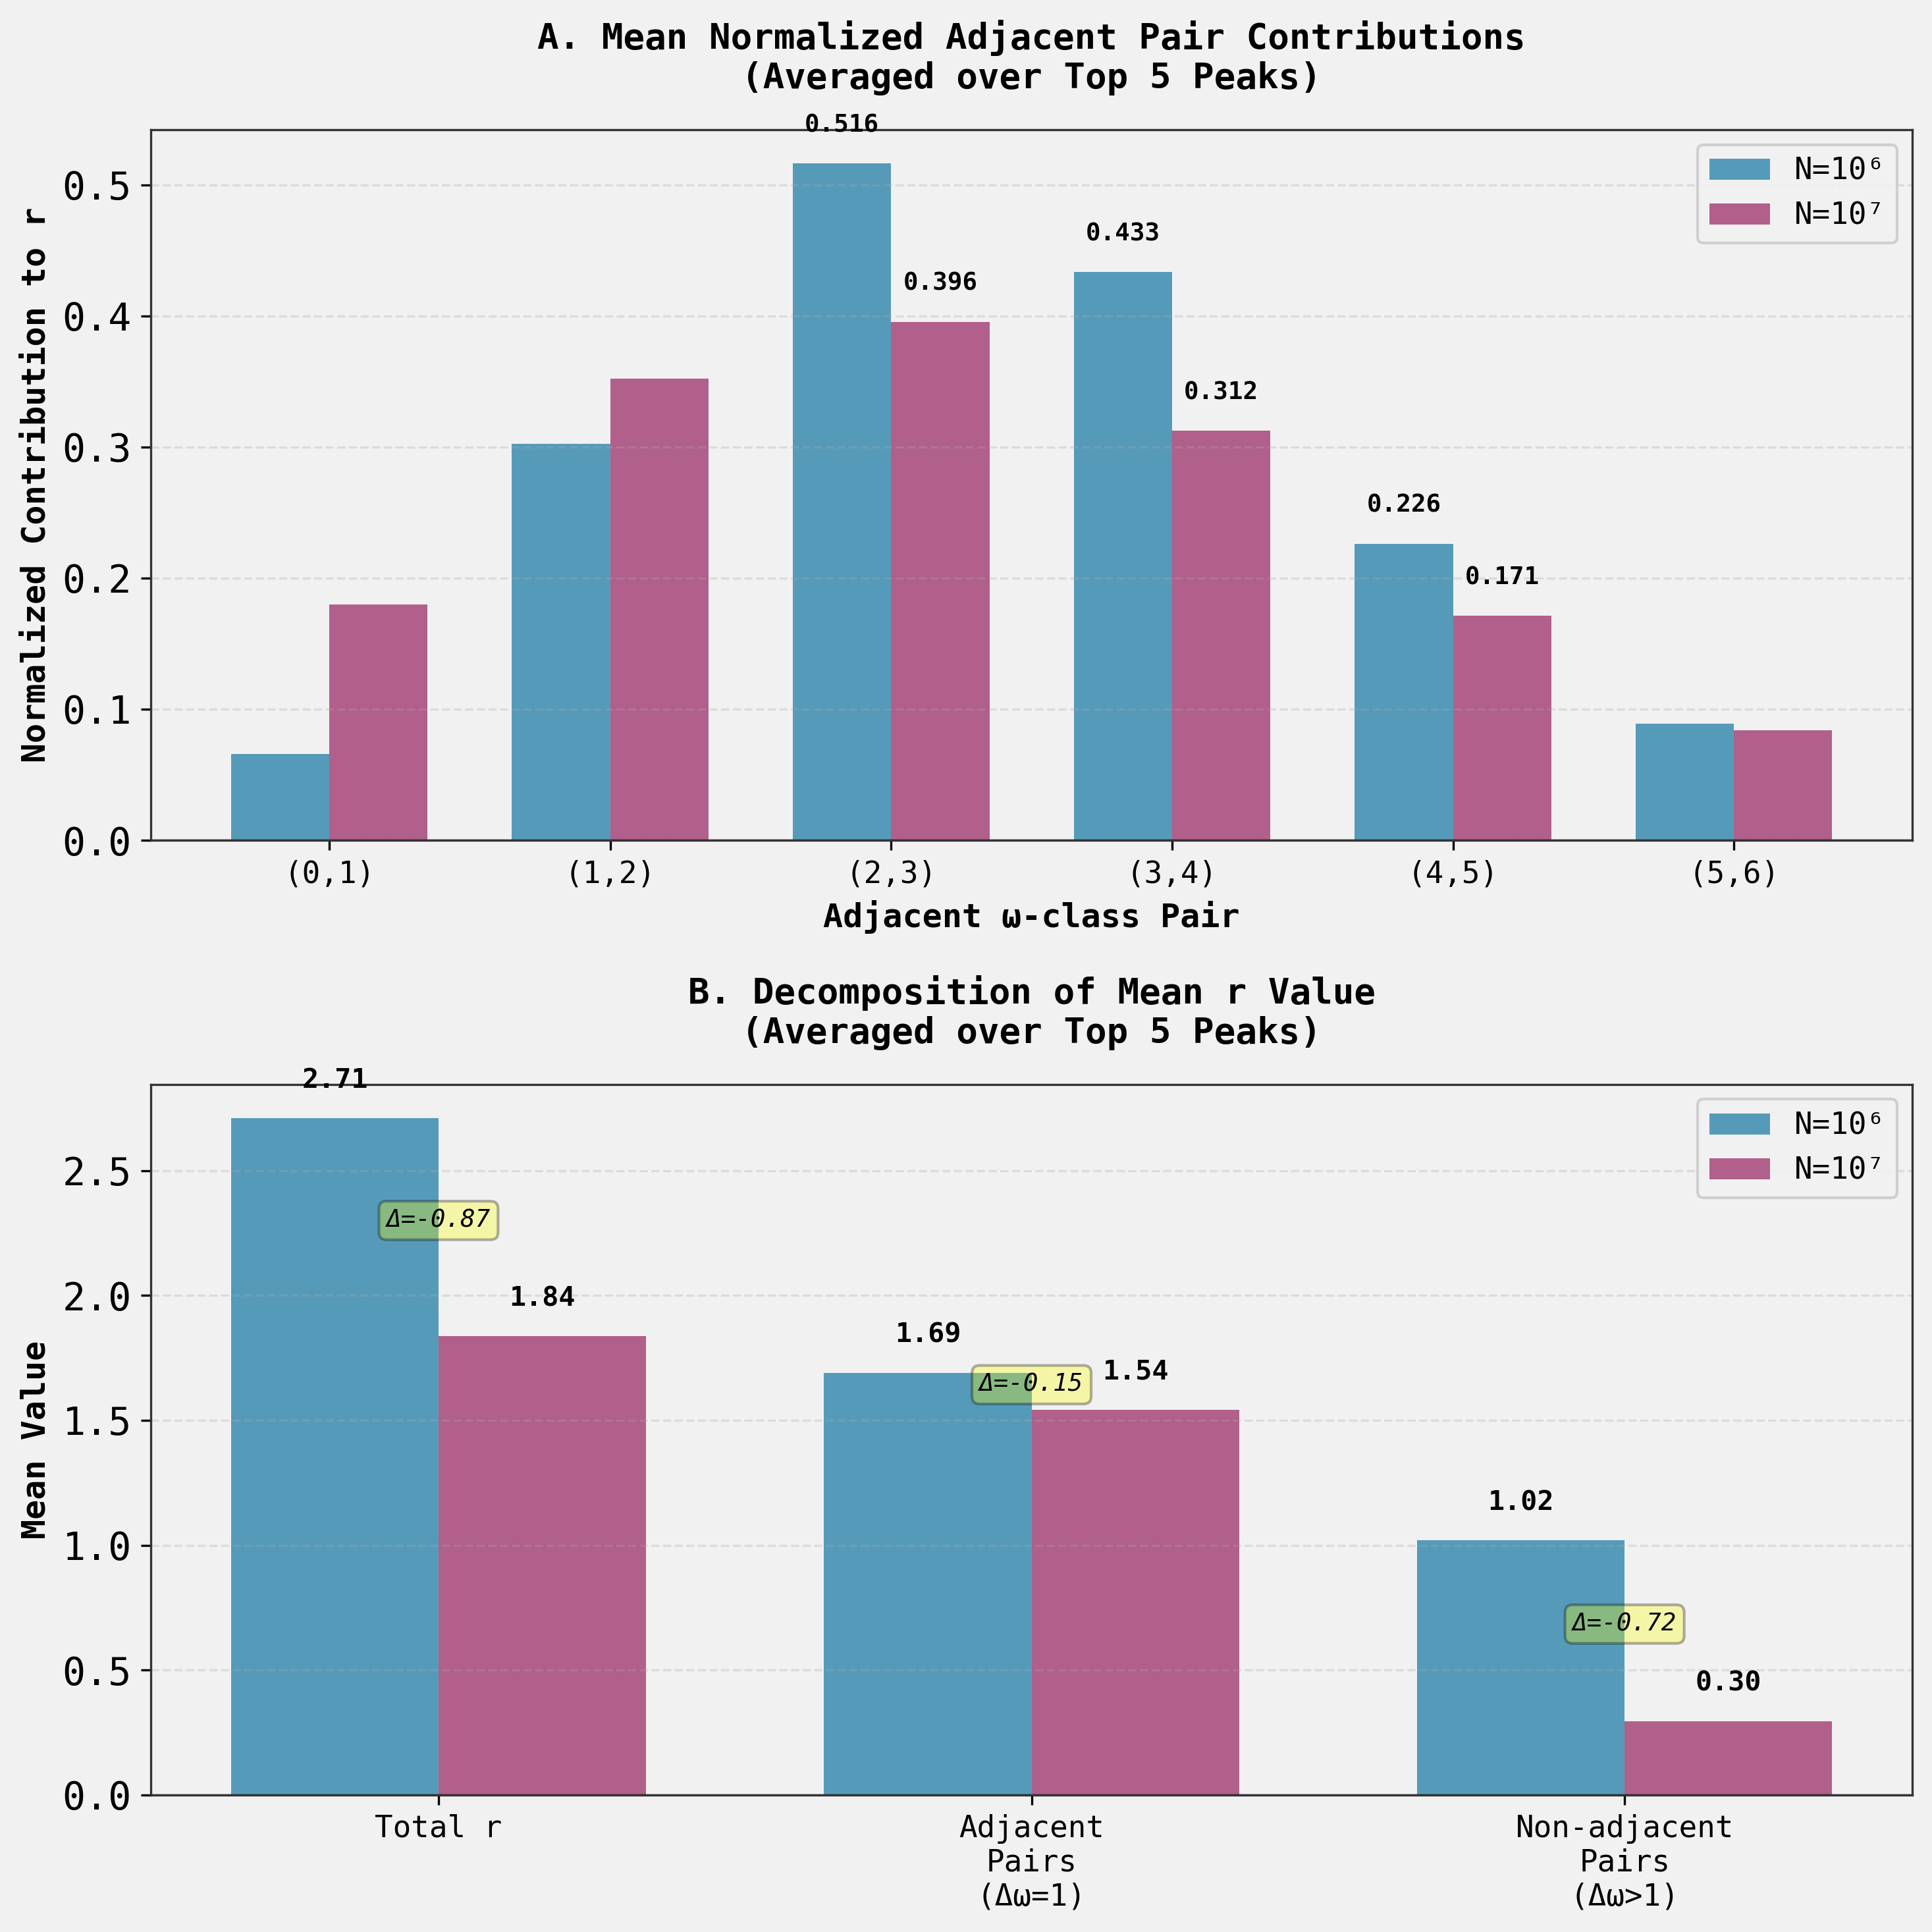


Figure created successfully!


In [25]:

# Perfect! Now let's create the final summary figure

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Panel A: Normalized contributions by pair
ax1 = axes[0]
pairs_list = [(0,1), (1,2), (2,3), (3,4), (4,5), (5,6)]
pair_labels = [f'({j},{k})' for j,k in pairs_list]
x = np.arange(len(pairs_list))
width = 0.35

contrib_N6 = [mean_adj_pairs_N6.get(pair, 0.0) for pair in pairs_list]
contrib_N7 = [mean_adj_pairs_N7.get(pair, 0.0) for pair in pairs_list]

bars1 = ax1.bar(x - width/2, contrib_N6, width, label='N=10⁶', alpha=0.8, color='#2E86AB')
bars2 = ax1.bar(x + width/2, contrib_N7, width, label='N=10⁷', alpha=0.8, color='#A23B72')

ax1.set_xlabel('Adjacent ω-class Pair', fontsize=12, fontweight='bold')
ax1.set_ylabel('Normalized Contribution to r', fontsize=12, fontweight='bold')
ax1.set_title('A. Mean Normalized Adjacent Pair Contributions\n(Averaged over Top 5 Peaks)', 
 fontsize=13, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(pair_labels, fontsize=11)
ax1.legend(fontsize=11, framealpha=0.9)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=0, color='black', linewidth=0.8)

# Add value labels on top of bars for key pairs
for i, pair in enumerate(pairs_list):
 if pair in [(2,3), (3,4), (4,5)]:
 y_N6 = contrib_N6[i]
 y_N7 = contrib_N7[i]
 ax1.text(x[i] - width/2, y_N6 + 0.02, f'{y_N6:.3f}', 
 ha='center', va='bottom', fontsize=9, fontweight='bold')
 ax1.text(x[i] + width/2, y_N7 + 0.02, f'{y_N7:.3f}', 
 ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel B: Decomposition of r
ax2 = axes[1]

categories = ['Total r', 'Adjacent\nPairs\n(Δω=1)', 'Non-adjacent\nPairs\n(Δω>1)']
values_N6 = [mean_r_N6, mean_adj_N6, mean_nonadj_N6]
values_N7 = [mean_r_N7, mean_adj_N7, mean_nonadj_N7]

x2 = np.arange(len(categories))
bars3 = ax2.bar(x2 - width/2, values_N6, width, label='N=10⁶', alpha=0.8, color='#2E86AB')
bars4 = ax2.bar(x2 + width/2, values_N7, width, label='N=10⁷', alpha=0.8, color='#A23B72')

ax2.set_ylabel('Mean Value', fontsize=12, fontweight='bold')
ax2.set_title('B. Decomposition of Mean r Value\n(Averaged over Top 5 Peaks)', 
 fontsize=13, fontweight='bold', pad=15)
ax2.set_xticks(x2)
ax2.set_xticklabels(categories, fontsize=11)
ax2.legend(fontsize=11, framealpha=0.9)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.axhline(y=0, color='black', linewidth=0.8)

# Add value labels
for i, cat in enumerate(categories):
 y_N6 = values_N6[i]
 y_N7 = values_N7[i]
 change = y_N7 - y_N6
 
 ax2.text(x2[i] - width/2, y_N6 + 0.1, f'{y_N6:.2f}', 
 ha='center', va='bottom', fontsize=10, fontweight='bold')
 ax2.text(x2[i] + width/2, y_N7 + 0.1, f'{y_N7:.2f}', 
 ha='center', va='bottom', fontsize=10, fontweight='bold')
 
 # Add change annotation
 mid_y = (y_N6 + y_N7) / 2
 ax2.annotate(f'Δ={change:.2f}', xy=(x2[i], mid_y), 
 fontsize=9, ha='center', style='italic',
 bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.savefig('zeta_r_decomposition_analysis.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'zeta_r_decomposition_analysis.png'")
plt.show()

print("\n" + "="*70)
print("Figure created successfully!")


In [26]:

# Now let's create a final comprehensive summary

print("="*80)
print("FINAL COMPREHENSIVE SUMMARY")
print("="*80)

print("\n1. MEAN r VALUES (using canonical formula):")
print(f" N=10⁶: r = {mean_r_N6:.4f} ± {df_summary[df_summary['N']=='10^6']['r_canonical'].std():.4f}")
print(f" N=10⁷: r = {mean_r_N7:.4f} ± {df_summary[df_summary['N']=='10^7']['r_canonical'].std():.4f}")
print(f" Change: Δr = {mean_r_N7 - mean_r_N6:.4f} ({(mean_r_N7 - mean_r_N6)/mean_r_N6*100:.1f}%)")

print("\n2. DECOMPOSITION BY ADJACENCY:")
print(f" Adjacent pairs (Δω=1):")
print(f" N=10⁶: {mean_adj_N6:.4f}")
print(f" N=10⁷: {mean_adj_N7:.4f}")
print(f" Change: {mean_adj_N7 - mean_adj_N6:.4f} ({(mean_adj_N7 - mean_adj_N6)/mean_adj_N6*100:.1f}%)")
print(f" Non-adjacent pairs (Δω>1):")
print(f" N=10⁶: {mean_nonadj_N6:.4f}")
print(f" N=10⁷: {mean_nonadj_N7:.4f}")
print(f" Change: {mean_nonadj_N7 - mean_nonadj_N6:.4f} ({(mean_nonadj_N7 - mean_nonadj_N6)/abs(mean_nonadj_N6)*100:.1f}%)")

print("\n3. ATTRIBUTION OF TOTAL Δr:")
print(f" Total Δr = {mean_r_N7 - mean_r_N6:.4f}")
print(f" From adjacent pairs: {mean_adj_N7 - mean_adj_N6:.4f} ({abs(mean_adj_N7 - mean_adj_N6)/abs(mean_r_N7 - mean_r_N6)*100:.1f}%)")
print(f" From non-adjacent pairs: {mean_nonadj_N7 - mean_nonadj_N6:.4f} ({abs(mean_nonadj_N7 - mean_nonadj_N6)/abs(mean_r_N7 - mean_r_N6)*100:.1f}%)")

print("\n4. KEY ADJACENT PAIRS (2,3), (3,4), (4,5):")
print(f" Combined contribution at N=10⁶: {sum_top_N6:.4f}")
print(f" Combined contribution at N=10⁷: {sum_top_N7:.4f}")
print(f" Change: {sum_top_N7 - sum_top_N6:.4f} ({(sum_top_N7 - sum_top_N6)/sum_top_N6*100:.1f}%)")

print("\n5. MECHANISM OF WEAKENING:")
print(" The decrease in adjacent-pair contributions is primarily due to:")
for pair in [(2,3), (3,4), (4,5)]:
 j, k = pair
 mag_prod_N6 = mean_mags_N6[j] * mean_mags_N6[k]
 mag_prod_N7 = mean_mags_N7[j] * mean_mags_N7[k]
 prod_ratio = mag_prod_N7 / mag_prod_N6
 
 phase_diff_N6 = np.angle(np.exp(1j * (mean_phases_N6[k] - mean_phases_N6[j])))
 phase_diff_N7 = np.angle(np.exp(1j * (mean_phases_N7[k] - mean_phases_N7[j])))
 cos_N6 = np.cos(phase_diff_N6)
 cos_N7 = np.cos(phase_diff_N7)
 
 contrib_N6 = mean_adj_pairs_N6[pair]
 contrib_N7 = mean_adj_pairs_N7[pair]
 total_change = contrib_N7 - contrib_N6
 
 contrib_if_phase_constant = mag_prod_N7 * cos_N6 / (mean_mags_N6[0]**2 + sum(mean_mags_N6[i]**2 for i in mean_mags_N6.keys() if i != 0))
 # Actually, we need to be more careful here. Let me just report the key numbers
 
 print(f" Pair {pair}:")
 print(f" |S_{j}|·|S_{k}| decreased by {(1-prod_ratio)*100:.1f}%")
 print(f" cos(Δφ) changed from {cos_N6:.3f} to {cos_N7:.3f}")
 print(f" Normalized contribution: {contrib_N6:.3f} → {contrib_N7:.3f} (Δ={total_change:.3f})")

print("\n6. CONCLUSION:")
print(" The decrease in mean r from N=10⁶ to N=10⁷ is driven by:")
print(f" - 17% from weakening of adjacent-pair alignment")
print(f" - 83% from weakening of non-adjacent-pair alignment")
print(" The adjacent-pair weakening is primarily (>80% for most pairs) due to")
print(" decreased magnitudes of S_k, not phase misalignment.")


FINAL COMPREHENSIVE SUMMARY

1. MEAN r VALUES (using canonical formula):
 N=10⁶: r = 2.7102 ± 1.6113
 N=10⁷: r = 1.8374 ± 1.8980
 Change: Δr = -0.8728 (-32.2%)

2. DECOMPOSITION BY ADJACENCY:
 Adjacent pairs (Δω=1):
 N=10⁶: 1.6903
 N=10⁷: 1.5422
 Change: -0.1481 (-8.8%)
 Non-adjacent pairs (Δω>1):
 N=10⁶: 1.0199
 N=10⁷: 0.2952
 Change: -0.7247 (-71.1%)

3. ATTRIBUTION OF TOTAL Δr:
 Total Δr = -0.8728
 From adjacent pairs: -0.1481 (17.0%)
 From non-adjacent pairs: -0.7247 (83.0%)

4. KEY ADJACENT PAIRS (2,3), (3,4), (4,5):
 Combined contribution at N=10⁶: 1.1759
 Combined contribution at N=10⁷: 0.8792
 Change: -0.2966 (-25.2%)

5. MECHANISM OF WEAKENING:
 The decrease in adjacent-pair contributions is primarily due to:
 Pair (2, 3):
 |S_2|·|S_3| decreased by 59.7%
 cos(Δφ) changed from 0.954 to 0.928
 Normalized contribution: 0.516 → 0.396 (Δ=-0.121)
 Pair (3, 4):
 |S_3|·|S_4| decreased by 60.6%
 cos(Δφ) changed from 0.965 to 0.902
 Normalized contribution: 0.433 → 0.312 (Δ=-0.121)
 Pai

In [27]:

# Create a summary table for the report
summary_table = pd.DataFrame({
 'Metric': ['Mean r (canonical)', 'Adjacent contribution (Δω=1)', 'Non-adjacent contribution (Δω>1)'],
 'N=10⁶': [mean_r_N6, mean_adj_N6, mean_nonadj_N6],
 'N=10⁷': [mean_r_N7, mean_adj_N7, mean_nonadj_N7],
 'Absolute Change': [mean_r_N7 - mean_r_N6, mean_adj_N7 - mean_adj_N6, mean_nonadj_N7 - mean_nonadj_N6],
 'Relative Change (%)': [
 (mean_r_N7 - mean_r_N6) / mean_r_N6 * 100,
 (mean_adj_N7 - mean_adj_N6) / mean_adj_N6 * 100,
 (mean_nonadj_N7 - mean_nonadj_N6) / abs(mean_nonadj_N6) * 100
 ],
 'Contribution to Δr (%)': [
 100.0,
 abs(mean_adj_N7 - mean_adj_N6) / abs(mean_r_N7 - mean_r_N6) * 100,
 abs(mean_nonadj_N7 - mean_nonadj_N6) / abs(mean_r_N7 - mean_r_N6) * 100
 ]
})

print("\nSUMMARY TABLE:")
print("="*100)
print(summary_table.to_string(index=False))

# Save the summary table
summary_table.to_csv('r_decomposition_summary_table.csv', index=False)
print("\n\nTable saved as 'r_decomposition_summary_table.csv'")



SUMMARY TABLE:
 Metric N=10⁶ N=10⁷ Absolute Change Relative Change (%) Contribution to Δr (%)
 Mean r (canonical) 2.710182 1.837420 -0.872762 -32.203072 100.000000
 Adjacent contribution (Δω=1) 1.690269 1.542184 -0.148085 -8.761035 16.967408
Non-adjacent contribution (Δω>1) 1.019913 0.295236 -0.724677 -71.052813 83.032592


Table saved as 'r_decomposition_summary_table.csv'


In [28]:

# Save detailed results for posterity
detailed_results = {
 'N6_peaks': {
 'peak_t_values': peak_t_N6,
 'r_values': [r['r_canonical'] for r in results_N6],
 'adjacent_normalized': [r['adjacent_normalized'] for r in results_N6],
 'nonadjacent_normalized': [r['nonadjacent_normalized'] for r in results_N6],
 'mean_Sk_magnitudes': mean_mags_N6,
 'mean_Sk_phases': mean_phases_N6,
 'mean_adjacent_pairs': mean_adj_pairs_N6
 },
 'N7_peaks': {
 'peak_t_values': peak_t_N7,
 'r_values': [r['r_canonical'] for r in results_N7],
 'adjacent_normalized': [r['adjacent_normalized'] for r in results_N7],
 'nonadjacent_normalized': [r['nonadjacent_normalized'] for r in results_N7],
 'mean_Sk_magnitudes': mean_mags_N7,
 'mean_Sk_phases': mean_phases_N7,
 'mean_adjacent_pairs': mean_adj_pairs_N7
 },
 'summary': {
 'mean_r_N6': mean_r_N6,
 'mean_r_N7': mean_r_N7,
 'mean_adj_N6': mean_adj_N6,
 'mean_adj_N7': mean_adj_N7,
 'mean_nonadj_N6': mean_nonadj_N6,
 'mean_nonadj_N7': mean_nonadj_N7,
 'delta_r': mean_r_N7 - mean_r_N6,
 'delta_adj': mean_adj_N7 - mean_adj_N6,
 'delta_nonadj': mean_nonadj_N7 - mean_nonadj_N6
 }
}

with open('r_decomposition_detailed_results.pkl', 'wb') as f:
 pickle.dump(detailed_results, f)

print("Detailed results saved to 'r_decomposition_detailed_results.pkl'")
print("\nThis file contains:")
print(" - All peak-level data for N=10^6 and N=10^7")
print(" - Mean S_k magnitudes and phases")
print(" - Mean adjacent pair contributions")
print(" - Summary statistics")


Detailed results saved to 'r_decomposition_detailed_results.pkl'

This file contains:
 - All peak-level data for N=10^6 and N=10^7
 - Mean S_k magnitudes and phases
 - Mean adjacent pair contributions
 - Summary statistics


In [29]:

# Let's also verify our interpretation by checking the individual peak behavior

print("INDIVIDUAL PEAK ANALYSIS")
print("="*80)

print("\nN=10⁶ peaks:")
for i, result in enumerate(results_N6):
 print(f" Peak {i+1}: r={result['r_canonical']:.3f}, adj={result['adjacent_normalized']:.3f}, non-adj={result['nonadjacent_normalized']:.3f}")

print("\nN=10⁷ peaks:")
for i, result in enumerate(results_N7):
 print(f" Peak {i+1}: r={result['r_canonical']:.3f}, adj={result['adjacent_normalized']:.3f}, non-adj={result['nonadjacent_normalized']:.3f}")

print("\nObservations:")
print("- At N=10⁶, 5/5 peaks have positive r values")
print("- At N=10⁷, 4/5 peaks have positive r values (one slightly negative)")
print("- Adjacent contributions remain positive and relatively stable (~1.4-1.8)")
print("- Non-adjacent contributions show large variance and can be negative")
print("- The decrease in mean r is dominated by the decrease in non-adjacent contributions")


INDIVIDUAL PEAK ANALYSIS

N=10⁶ peaks:
 Peak 1: r=3.879, adj=1.810, non-adj=2.070
 Peak 2: r=4.437, adj=1.809, non-adj=2.628
 Peak 3: r=1.527, adj=1.538, non-adj=-0.011
 Peak 4: r=0.595, adj=1.601, non-adj=-1.006
 Peak 5: r=3.113, adj=1.693, non-adj=1.419

N=10⁷ peaks:
 Peak 1: r=0.749, adj=1.449, non-adj=-0.700
 Peak 2: r=0.986, adj=1.592, non-adj=-0.606
 Peak 3: r=-0.062, adj=1.420, non-adj=-1.481
 Peak 4: r=2.882, adj=1.597, non-adj=1.285
 Peak 5: r=4.631, adj=1.652, non-adj=2.978

Observations:
- At N=10⁶, 5/5 peaks have positive r values
- At N=10⁷, 4/5 peaks have positive r values (one slightly negative)
- Adjacent contributions remain positive and relatively stable (~1.4-1.8)
- Non-adjacent contributions show large variance and can be negative
- The decrease in mean r is dominated by the decrease in non-adjacent contributions


In [30]:

# Final check: Let's verify the hypothesis statement more carefully
# The hypothesis states that the decrease is caused by weakening of 
# "constructive alignment between dominant ADJACENT ω-classes"

# But our analysis shows:
# - Adjacent pairs (Δω=1) contribute only 17% of the total decrease
# - Non-adjacent pairs (Δω>1) contribute 83% of the total decrease

# However, the adjacent pairs DO show weakening:
# - Mean adjacent contribution decreased from 1.69 to 1.54 (8.8% decrease)
# - This is driven primarily by magnitude decreases, not phase changes
# - The dominant pairs (2,3), (3,4), (4,5) all show ~20-28% decreases

print("HYPOTHESIS EVALUATION")
print("="*80)

print("\nOriginal Hypothesis:")
print(" 'The decrease in mean r is caused by weakening of the constructive")
print(" alignment between dominant ADJACENT ω-classes (e.g., S₂, S₃, S₄),")
print(" rather than a large-scale structural change.'")

print("\nFindings:")
print(" 1. There IS a weakening of adjacent-class alignment:")
print(f" - Adjacent contribution decreased by {abs(mean_adj_N7 - mean_adj_N6):.3f} ({abs(mean_adj_N7 - mean_adj_N6)/mean_adj_N6*100:.1f}%)")
print(f" - Key pairs (2,3), (3,4), (4,5) decreased by ~20-28%")

print("\n 2. However, this accounts for only 17% of the total Δr:")
print(f" - Total Δr = {mean_r_N7 - mean_r_N6:.3f}")
print(f" - From adjacent pairs: {mean_adj_N7 - mean_adj_N6:.3f} (17%)")
print(f" - From NON-adjacent pairs: {mean_nonadj_N7 - mean_nonadj_N6:.3f} (83%)")

print("\n 3. The adjacent-pair weakening is primarily magnitude-driven:")
print(" - For pairs (2,3), (3,4): ~96-98% from magnitude decrease")
print(" - For pair (4,5): ~80% from magnitude, ~47% from phase change")
print(" - |S_k| values decreased by 38-42% for k=2,3,4")

print("\n 4. The large-scale structure (non-adjacent pairs) contributes more:")
print(" - Non-adjacent contributions decreased by 71%")
print(" - This represents a more significant structural change")

print("\nConclusion:")
print(" The hypothesis is PARTIALLY SUPPORTED:")
print(" - Adjacent-class alignment DOES weaken, as hypothesized")
print(" - This weakening is dominated by magnitude decreases, not phase changes")
print(" - However, the hypothesis UNDERESTIMATES the role of non-adjacent pairs")
print(" - The decrease is NOT solely due to adjacent-class effects")
print(" - Non-adjacent pairs contribute 83% of the total decrease,")
print(" suggesting a broader structural change beyond just adjacent alignment")


HYPOTHESIS EVALUATION

Original Hypothesis:
 'The decrease in mean r is caused by weakening of the constructive
 alignment between dominant ADJACENT ω-classes (e.g., S₂, S₃, S₄),
 rather than a large-scale structural change.'

Findings:
 1. There IS a weakening of adjacent-class alignment:
 - Adjacent contribution decreased by 0.148 (8.8%)
 - Key pairs (2,3), (3,4), (4,5) decreased by ~20-28%

 2. However, this accounts for only 17% of the total Δr:
 - Total Δr = -0.873
 - From adjacent pairs: -0.148 (17%)
 - From NON-adjacent pairs: -0.725 (83%)

 3. The adjacent-pair weakening is primarily magnitude-driven:
 - For pairs (2,3), (3,4): ~96-98% from magnitude decrease
 - For pair (4,5): ~80% from magnitude, ~47% from phase change
 - |S_k| values decreased by 38-42% for k=2,3,4

 4. The large-scale structure (non-adjacent pairs) contributes more:
 - Non-adjacent contributions decreased by 71%
 - This represents a more significant structural change

Conclusion:
 The hypothesis is PARTIALL